## Homework 4: EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

March 27, 2025 | MUSA 6500

Jun, Youngang <br> Student of Master of Urban Spatial Analytics Program <br> Stuart Weitzman School of Design <br> University of Pennsylvania



This assignment aims to analyze land use and land cover classification using the EuroSAT multispectral (MS) and RGB datasets. To achieve this, machine learning and deep learning were applied using Python.

### 1. Data Loading, Processing, and Exploration

#### 1.1 Exploratory Data Analysis

The multispectral dataset (MS) contains a total of **27,000 tif files**, and the RGB dataset contains **27,000 jpg files**. Each dataset includes 10 classes: **Forest, River, Highway, AnnualCrop, SeaLake, HerbaceousVegetation, Industrial, Residential, PermanentCrop, and Pasture**, with **2,000-3,000 images per class**. The class distributions are shown in the following bar charts.

In [101]:
# Load necessary libraries
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from collections import Counter
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from keras.utils import plot_model, to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.optimizers import Adam
from IPython.display import Image

In [102]:
# Set directory
MS_dir = "./EuroSAT_MS"
RGB_dir = "./EuroSAT_RGB"

# Import all MS (tif) and RGB (jpg) files
MS_tif = glob.glob(os.path.join(MS_dir, "**/*.tif"), recursive=True)
RGB_jpg = glob.glob(os.path.join(RGB_dir, "**/*.jpg"), recursive=True)

print(f"Total MS tif files: {len(MS_tif)} / Total RGB jpg files: {len(RGB_jpg)}")

Total MS tif files: 27000 / Total RGB jpg files: 27000


Number of Classes: 10 classes
- Forest: 3000 images
- River: 2500 images
- Highway: 2500 images
- AnnualCrop: 3000 images
- SeaLake: 3000 images
- HerbaceousVegetation: 3000 images
- Industrial: 2500 images
- Residential: 3000 images
- PermanentCrop: 2500 images
- Pasture: 2000 images


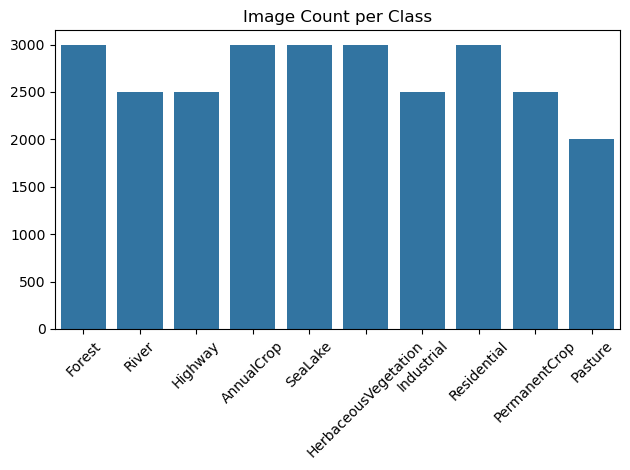

In [103]:
# Count the number of RGB images per class
class_counts = {cls: len(files) for cls in os.listdir(RGB_dir)
                if os.path.isdir(os.path.join(RGB_dir, cls))
                for files in [os.listdir(os.path.join(RGB_dir, cls))]}

print(f"Number of Classes: {len(class_counts)} classes")

# Class distribution of RGB images
for cls, count in class_counts.items():
    print(f"- {cls}: {count} images")

# Bar chart of class distribution of RGB images
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("Image Count per Class")
plt.tight_layout()
plt.show()

Number of Classes: 10 classes
- Forest: 3000 images
- River: 2500 images
- Highway: 2500 images
- AnnualCrop: 3000 images
- SeaLake: 3000 images
- HerbaceousVegetation: 3000 images
- Industrial: 2500 images
- Residential: 3000 images
- PermanentCrop: 2500 images
- Pasture: 2000 images


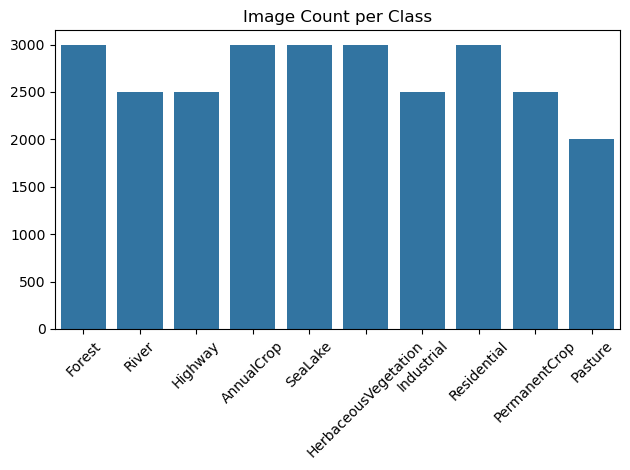

In [104]:
# Count the number of MS images per class
class_counts = {cls: len(files) for cls in os.listdir(MS_dir)
                if os.path.isdir(os.path.join(MS_dir, cls))
                for files in [os.listdir(os.path.join(MS_dir, cls))]}

print(f"Number of Classes: {len(class_counts)} classes")

# Class distribution of MS images
for cls, count in class_counts.items():
    print(f"- {cls}: {count} images")

# Bar chart of class distribution of MS images
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("Image Count per Class")
plt.tight_layout()
plt.show()

The following 2×5 grid shows one RGB image from each class.

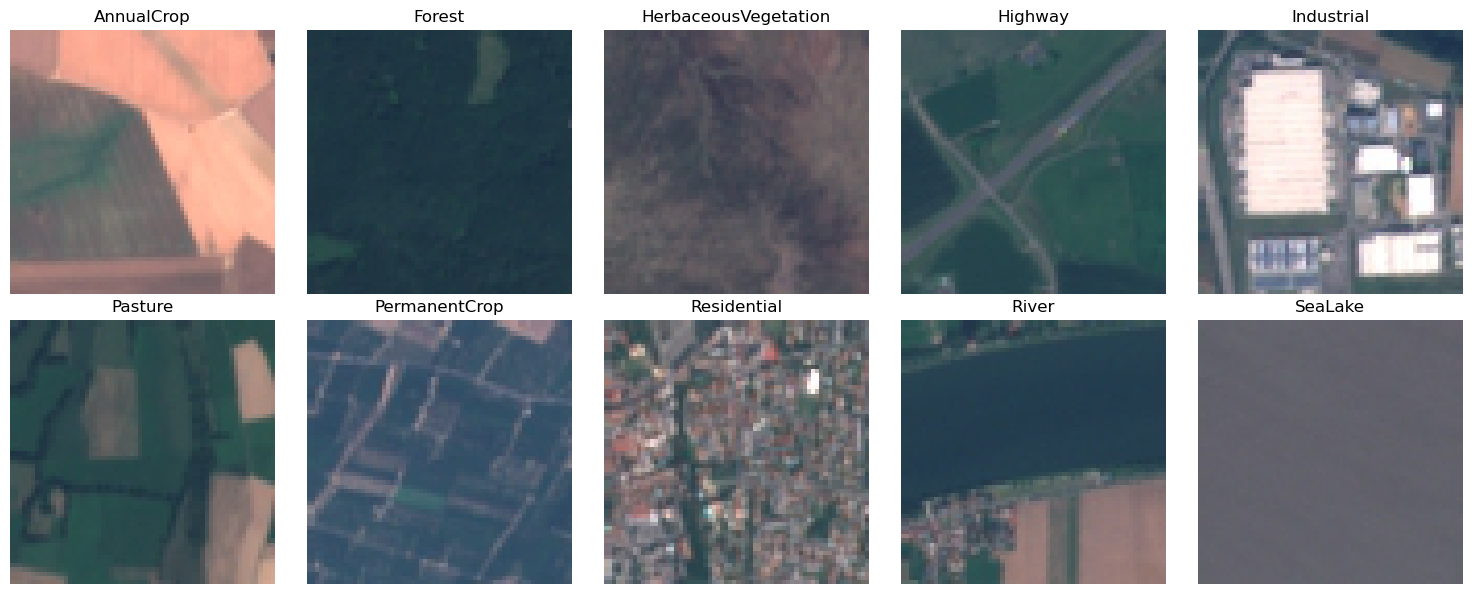

In [105]:
from PIL import Image
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(sorted(class_counts.keys())):  
    class_dir = os.path.join(RGB_dir, cls)
    image_file = os.listdir(class_dir)[2]  # pick third image
    image_path = os.path.join(class_dir, image_file)

    img = Image.open(image_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

The following 2×5 grid shows one MS (selected 4, 3, and 2 band for red, green, and blue respectively) image from each class.

In [106]:
def load_rgb_from_tif(tif_path):
    with rasterio.open(tif_path) as src:
        # Read bands 4, 3, 2 (1-indexed in rasterio)
        red = src.read(4)
        green = src.read(3)
        blue = src.read(2)
        
        # Stack and normalize to 0-1 for visualization
        rgb = np.stack([red, green, blue], axis=-1).astype(np.float32)
        rgb /= np.max(rgb) + 1e-5  # Normalize for display
    return rgb

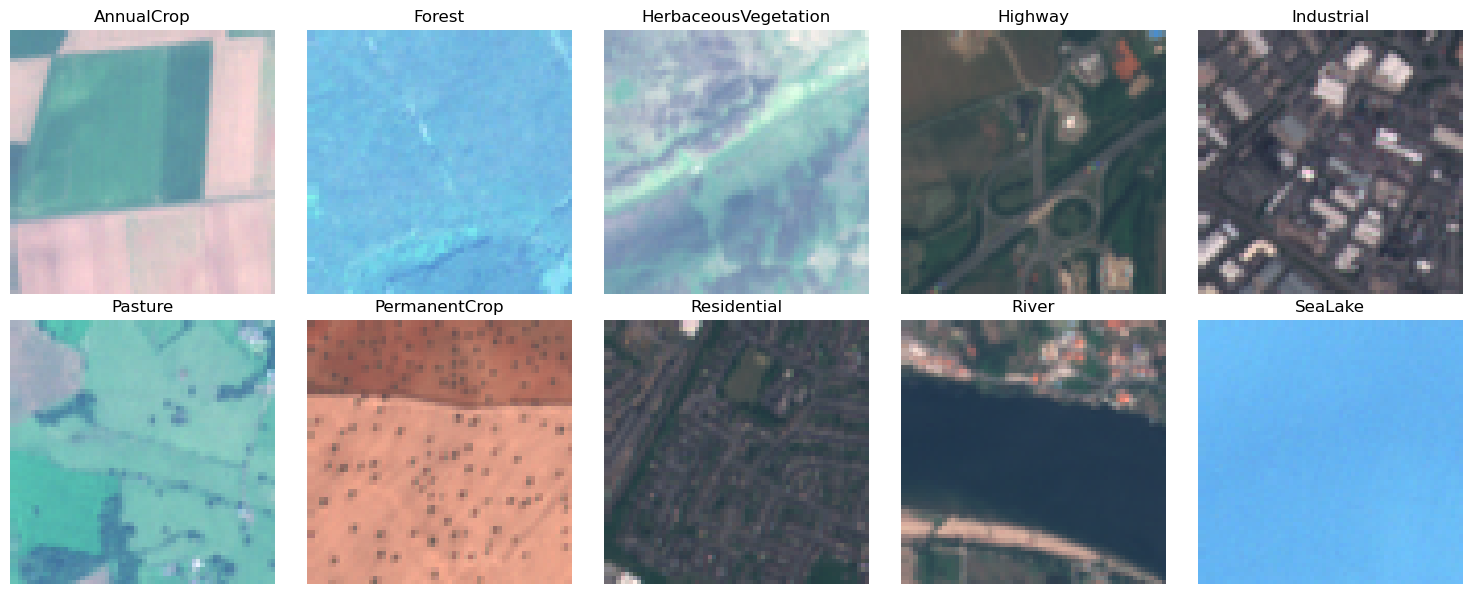

In [107]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

ms_classes = sorted([
    d for d in os.listdir(MS_dir)
    if os.path.isdir(os.path.join(MS_dir, d))
])

for idx, cls in enumerate(ms_classes):
    class_dir = os.path.join(MS_dir, cls)
    tif_file = os.listdir(class_dir)[2]  # pick third image
    tif_path = os.path.join(class_dir, tif_file)
    
    rgb_image = load_rgb_from_tif(tif_path)
    
    axes[idx].imshow(rgb_image)
    axes[idx].set_title(cls)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

The following code chunk flattens the MS images into a 2D data matrix of shape (n x p), where n is the number of samples and p is the number of pixels per image. The images and labels are loaded into NumPy arrays. The resulting array has shape (27,000 × 53,248), where 27,000 is the total number of MS images, and **53,248** is the number of pixels per image. Each image consists of **64 × 64 pixels** across **13 spectral bands**.

In [108]:
X = []
y = []

class_names = sorted([
    d for d in os.listdir(MS_dir)
    if os.path.isdir(os.path.join(MS_dir, d))
])

for class_name in tqdm(class_names, desc="Loading images"):
    class_path = os.path.join(MS_dir, class_name)
    for file in os.listdir(class_path):
        if file.endswith(".tif"):
            img_path = os.path.join(class_path, file)
            with rasterio.open(img_path) as src:
                img = src.read()  # Shape: (bands, height, width)
                img = np.transpose(img, (1, 2, 0))  # (H, W, C)
                img_array = img.flatten()
                X.append(img_array)
                y.append(class_name)

X = np.array(X)
y = np.array(y)
print(f"Dataset shape: {X.shape}, Labels shape: {y.shape}")

Loading images: 100%|██████████| 10/10 [01:11<00:00,  7.15s/it]


Dataset shape: (27000, 53248), Labels shape: (27000,)


The dataset is split into training (60%) and testing (40%) sets. The labels were encoded by number using `LabelEncoder`. Using `stratify=y_encoded`, the split preserves the class distribution, ensuring that there is an equal percentage of each class type in each of both training and testing sets. The data augmentation was not applied in this assignment.

In [109]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (16200, 53248), Test shape: (10800, 53248)


A grayscale version of this dataset was created by calculate average of red, green, and blue band, as shown in the following code chunk. This is used for the traditional machine learning models and the first couple of deep learning models. The number of pixels per image is **4,096**, as a 64 × 64 image is flattened into **one-dimensional vector**.

In [110]:
X_gray = []

for class_name in tqdm(class_names, desc="Loading grayscale images"):
    class_path = os.path.join(MS_dir, class_name)
    for file in os.listdir(class_path):
        if file.endswith(".tif"):
            img_path = os.path.join(class_path, file)
            with rasterio.open(img_path) as src:
                try:
                    # Read bands 4 (Red), 3 (Green), 2 (Blue)
                    red = src.read(4).astype(np.float32)
                    green = src.read(3).astype(np.float32)
                    blue = src.read(2).astype(np.float32)

                    # Grayscale = average of RGB bands
                    gray = (red + green + blue) / 3.0
                    gray_flat = gray.flatten()
                    X_gray.append(gray_flat)
                except Exception as e:
                    print(f"Error reading {img_path}: {e}")

X_gray = np.array(X_gray)

# Split grayscale version with same stratification
X_gray_train, X_gray_test, _, _ = train_test_split(
    X_gray, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

print(f"Grayscale train shape: {X_gray_train.shape}, test shape: {X_gray_test.shape}")

Loading grayscale images: 100%|██████████| 10/10 [01:12<00:00,  7.20s/it]


Grayscale train shape: (16200, 4096), test shape: (10800, 4096)


### 2. Traditional Machine Learning

In the Section 2, only the categories "Forest (F)", "Residential (R)" and "Industrial (I)" in the grayscale dataset was used.

In [111]:
target_classes = ["Forest", "Residential", "Industrial"]

# Get indices of images with target labels
selected_indices = [i for i, label in enumerate(y) if label in target_classes]

# Subset the grayscale data and labels
X_gray_filtered = X_gray[selected_indices]
y_filtered = y[selected_indices]

# Encode labels again, but only with the 3 classes
le_filtered = LabelEncoder()
y_filtered_encoded = le_filtered.fit_transform(y_filtered)

In [112]:
X_gray_train, X_gray_test, y_gray_train, y_gray_test = train_test_split(
    X_gray_filtered, y_filtered_encoded,
    test_size=0.4,
    random_state=42,
    stratify=y_filtered_encoded
)

print("Train shape:", X_gray_train.shape)
print("Test shape:", X_gray_test.shape)

Train shape: (5100, 4096)
Test shape: (3400, 4096)


#### 2.1 Binary Support Vector Machine

`train_and_evaluate_binary_svm` is a function that defines a binary SVM classifier to classify [F vs R], [F vs I] and [R vs I] using a linear kernel with default parameters. As a result of running the function, the F vs R and F vs I classifiers showed very high accuracies of 0.9267 and 0.9936, and AUCs of 0.99 and 1.00, respectively. In contrast, the R vs I classifier achieved a lower accuracy of 0.7141 and an AUC of 0.75. The following images are grayscale images that is one of the mis-classified by each classifier, including both the predicted label and the ground truth.

In [113]:
# Function to classify and evaluate binary SVM
def train_and_evaluate_binary_svm(X_train, X_test, y_train, y_test, label1, label2, class_names):
    # Filter data for the two classes
    mask_train = np.isin(y_train, [label1, label2])
    mask_test = np.isin(y_test, [label1, label2])

    X_bin_train = X_train[mask_train]
    X_bin_test = X_test[mask_test]
    y_bin_train = y_train[mask_train]
    y_bin_test = y_test[mask_test]

    # Convert labels to binary: label1 -> 0, label2 -> 1
    y_bin_train = (y_bin_train == label2).astype(int)
    y_bin_test = (y_bin_test == label2).astype(int)

    # Train SVM
    clf = SVC(kernel='linear', probability=True)
    clf.fit(X_bin_train, y_bin_train)

    # Predict
    y_pred = clf.predict(X_bin_test)
    y_score = clf.predict_proba(X_bin_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_bin_test, y_pred)
    print(f"Accuracy ({class_names[label1]} vs {class_names[label2]}): {acc:.4f}")

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(y_bin_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve: {class_names[label1]} vs {class_names[label2]}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Display misclassified image
    misclassified_indices = np.where(y_pred != y_bin_test)[0]
    if len(misclassified_indices) > 0:
        idx = misclassified_indices[0]
        img_flat = X_bin_test[idx]
        img = img_flat.reshape(64, 64)

        plt.imshow(img, cmap='gray')
        plt.title(f"Misclassified: Predicted={class_names[label2 if y_pred[idx] else label1]}, "
                  f"True={class_names[label2 if y_bin_test[idx] else label1]}")
        plt.axis('off')
        plt.show()
    else:
        print("No misclassified images in this pair.")

Accuracy (Forest vs Residential): 0.9267


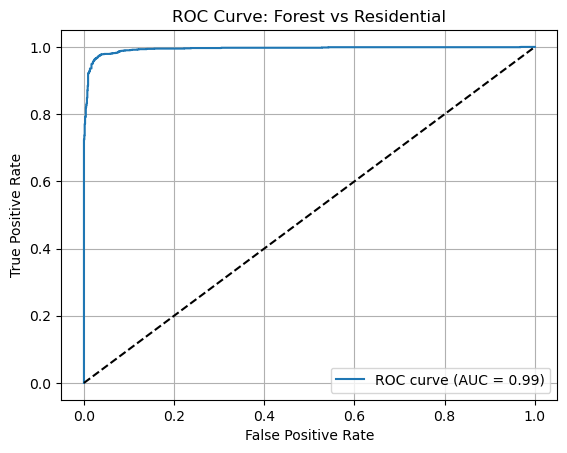

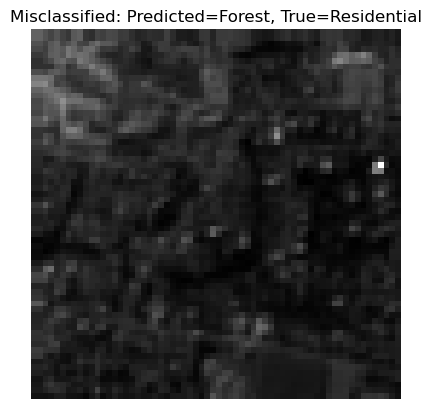

Accuracy (Forest vs Industrial): 0.9936


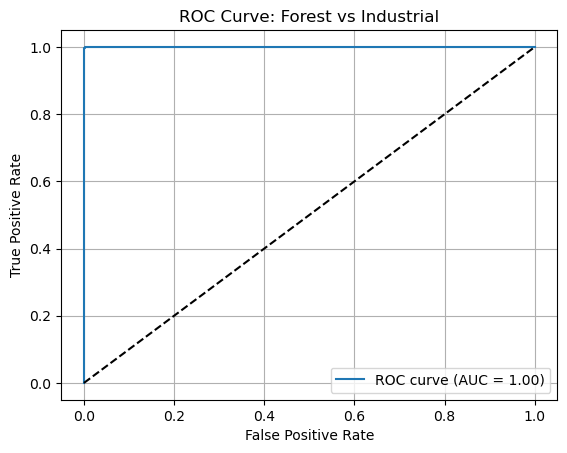

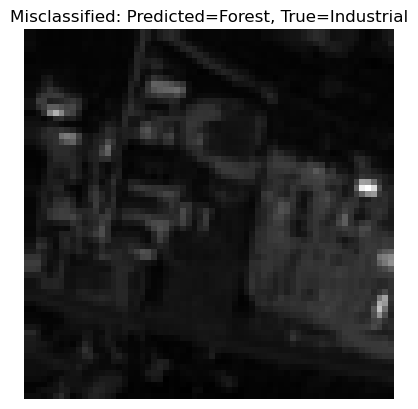

Accuracy (Residential vs Industrial): 0.7141


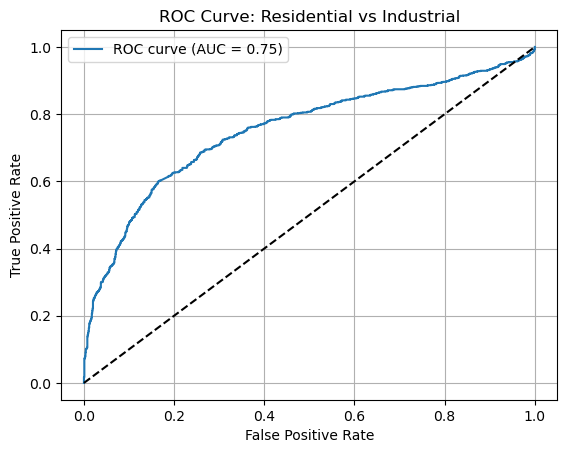

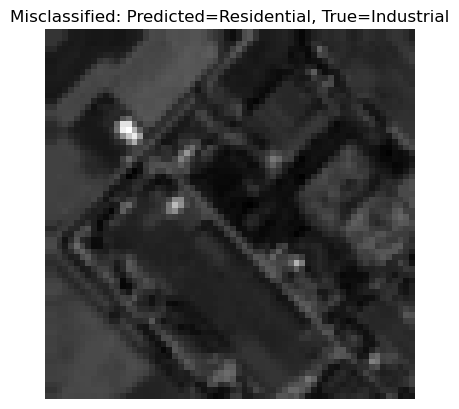

In [114]:
# Get class index mapping
class_mapping = {name: idx for idx, name in enumerate(le_filtered.classes_)}

# 1. Forest vs Residential
train_and_evaluate_binary_svm(
    X_gray_train, X_gray_test, y_gray_train, y_gray_test,
    label1=class_mapping['Forest'], label2=class_mapping['Residential'],
    class_names=le_filtered.classes_
)

# 2. Forest vs Industrial
train_and_evaluate_binary_svm(
    X_gray_train, X_gray_test, y_gray_train, y_gray_test,
    label1=class_mapping['Forest'], label2=class_mapping['Industrial'],
    class_names=le_filtered.classes_
)

# 3. Residential vs Industrial
train_and_evaluate_binary_svm(
    X_gray_train, X_gray_test, y_gray_train, y_gray_test,
    label1=class_mapping['Residential'], label2=class_mapping['Industrial'],
    class_names=le_filtered.classes_
)

#### 2.2 Multiclass, Majority-Vote Support Vector Machine

`predict_majority_vote` is a function that apply majority voting to decide the final class of the test sample at once. As a result of running the function, the accuracy of classification is 0.7650, and AUCs were 0.95 for F, 0.77 for I, 0.74 for R, respectively. The following images are grayscale images that is one of the mis-classified by each classifier, including both the predicted label and the ground truth.

In [115]:
def train_binary_svm(X_train, y_train, label1, label2):
    mask = np.isin(y_train, [label1, label2])
    X_binary = X_train[mask]
    y_binary = y_train[mask]
    y_binary = (y_binary == label2).astype(int)

    clf = SVC(kernel='linear', probability=True)
    clf.fit(X_binary, y_binary)
    return clf

In [116]:
# Class name -> index
class_map = {name: i for i, name in enumerate(le_filtered.classes_)}

# Train each binary SVM
svm_FR = train_binary_svm(X_gray_train, y_gray_train, class_map['Forest'], class_map['Residential'])
svm_FI = train_binary_svm(X_gray_train, y_gray_train, class_map['Forest'], class_map['Industrial'])
svm_RI = train_binary_svm(X_gray_train, y_gray_train, class_map['Residential'], class_map['Industrial'])

In [117]:
def predict_majority_vote(X):
    preds = []

    for x in X:
        votes = []

        # Forest vs Residential
        pred_fr = svm_FR.predict([x])[0]
        votes.append(class_map['Residential'] if pred_fr == 1 else class_map['Forest'])

        # Forest vs Industrial
        pred_fi = svm_FI.predict([x])[0]
        votes.append(class_map['Industrial'] if pred_fi == 1 else class_map['Forest'])

        # Residential vs Industrial
        pred_ri = svm_RI.predict([x])[0]
        votes.append(class_map['Industrial'] if pred_ri == 1 else class_map['Residential'])

        # Majority vote
        final_pred = max(set(votes), key=votes.count)
        preds.append(final_pred)

    return np.array(preds)

In [118]:
y_pred_majority = predict_majority_vote(X_gray_test)
accuracy = accuracy_score(y_gray_test, y_pred_majority)
print(f"Majority-Vote Multiclass Accuracy: {accuracy:.4f}")

Majority-Vote Multiclass Accuracy: 0.7650


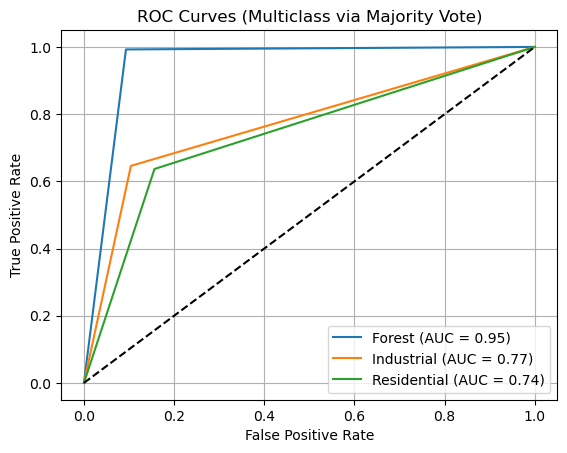

In [119]:
# Binarize labels for ROC
y_test_bin = label_binarize(y_gray_test, classes=[0, 1, 2])
y_pred_bin = label_binarize(y_pred_majority, classes=[0, 1, 2])

# Compute ROC and AUC for each class
for i, class_name in enumerate(le_filtered.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves (Multiclass via Majority Vote)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

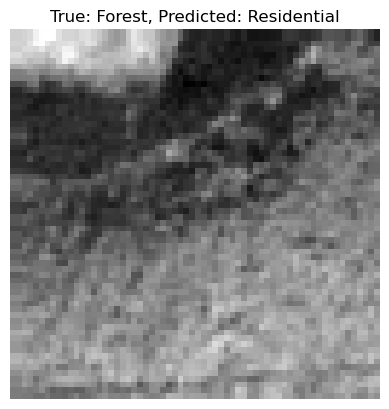

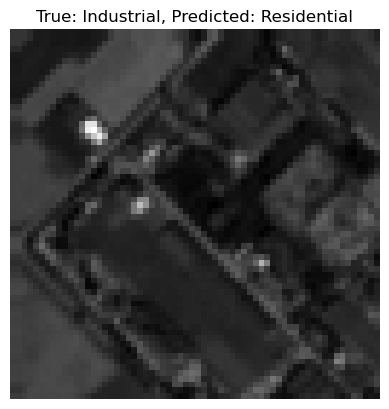

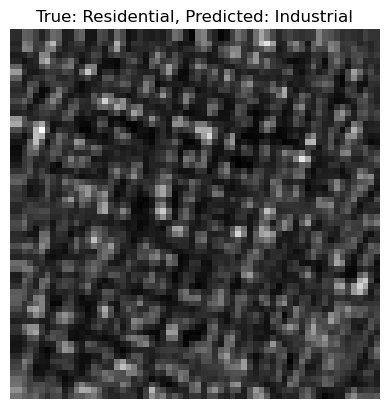

In [121]:
# Mis-classified images from each class
for i, class_name in enumerate(le_filtered.classes_):
    # Find test samples truly of class i
    true_indices = np.where(y_gray_test == i)[0]
    
    for idx in true_indices:
        if y_pred_majority[idx] != i:
            img = X_gray_test[idx].reshape(64, 64)
            pred_label = le_filtered.classes_[y_pred_majority[idx]]
            true_label = le_filtered.classes_[i]

            plt.imshow(img, cmap='gray')
            plt.title(f"True: {true_label}, Predicted: {pred_label}")
            plt.axis('off')
            plt.show()
            break  

#### 2.3 Multiclass Random Forest

In this section, a Random-Forest classifier was trained to classify the data into three classes. The model achieves an accuracy of 0.9118. The confusion matrix below shows that Forest is well distinguished from Residential and Industrial, while Residential and Industrial are often confused with each other.

In [122]:
# Train the Random-Forest classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_gray_train, y_gray_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_gray_test)

In [123]:
accuracy = accuracy_score(y_gray_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9118


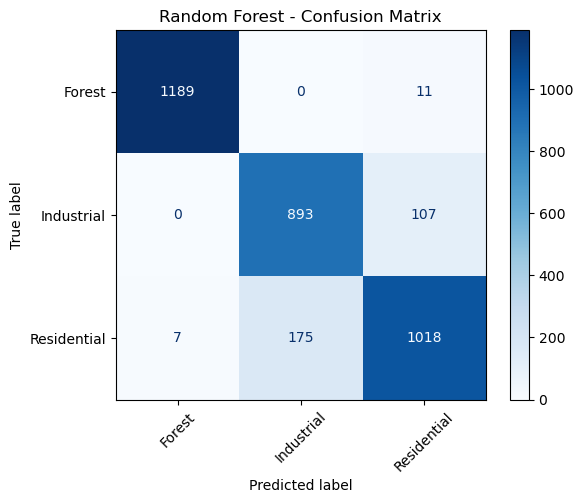

In [124]:
# Confusion Matrix
cm = confusion_matrix(y_gray_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_filtered.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.grid(False)
plt.show()

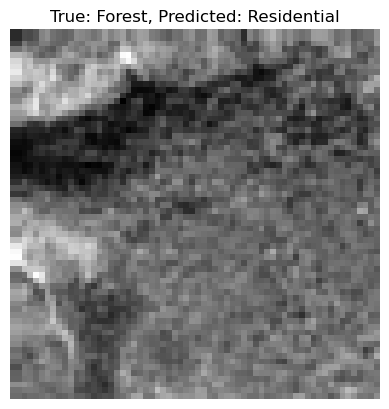

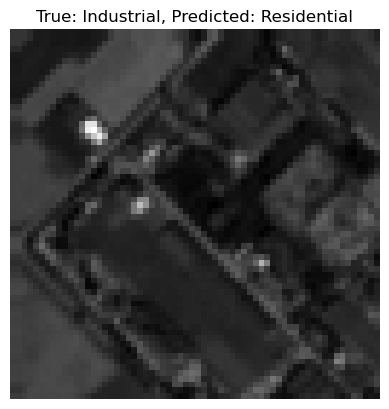

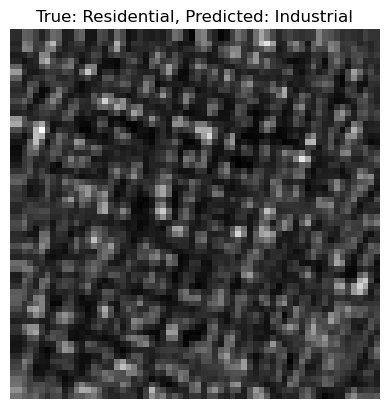

In [125]:
# Mis-classified images from each class
for i, class_name in enumerate(le_filtered.classes_):
    # Find test samples of class i
    true_indices = np.where(y_gray_test == i)[0]
    
    for idx in true_indices:
        if y_pred_rf[idx] != i:
            img = X_gray_test[idx].reshape(64, 64)
            pred_label = le_filtered.classes_[y_pred_rf[idx]]
            true_label = le_filtered.classes_[i]

            plt.imshow(img, cmap='gray')
            plt.title(f"True: {true_label}, Predicted: {pred_label}")
            plt.axis('off')
            plt.show()
            break  

### 3. Deep Learning

For Section 3, the full range of possible land cover categories were used.

#### 3.1 Greyscale Images

##### 3.1.1 Model 1

Model 1 is the first deep learning model, using a fully connected network with a single fully connected layer (i.e: input layer + fully connected layer as the output layer). 

To improve the quality of model training, the pre-process was conducted as the following steps: 

(1) idenfied the number of classes, 

(2) normalized image pixel values to the range [0, 1] by converting integers to floats and dividing by 255.0, and

(3) converted labels to one-hot encoded vectors. For example, label 2 is converted to [0, 0, 1, 0, ..., 0].

The model achieves the test accuracies of **0.3785, 0.4576, and 0.6344 at epochs 10, 15, and 20, respectively**. The network architecture visualization is as follows.

In [128]:
# Number of classes
num_classes = len(np.unique(y_encoded))

# Normalize image pixel values to [0, 1]
X_train_dl = X_gray_train.astype("float32") / 255.0 # train X deep learning
X_test_dl = X_gray_test.astype("float32") / 255.0 # test X deep learning

# One-hot encode labels
y_train_dl = to_categorical(y_gray_train, num_classes)
y_test_dl = to_categorical(y_gray_test, num_classes)

In [172]:
model = Sequential()
model.add(Input(shape=(4096,)))  # 64x64 → 4,096 demension
model.add(Dense(num_classes, activation='softmax'))  # output with number of classes

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()  # output model summary

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

In [173]:
history = model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=2
)

Epoch 1/20
36/36 - 0s - 6ms/step - accuracy: 0.3793 - loss: 4.5978 - val_accuracy: 0.3627 - val_loss: 1.4285
Epoch 2/20
36/36 - 0s - 1ms/step - accuracy: 0.4126 - loss: 1.4391 - val_accuracy: 0.5608 - val_loss: 1.3820
Epoch 3/20
36/36 - 0s - 1ms/step - accuracy: 0.4425 - loss: 1.3396 - val_accuracy: 0.3333 - val_loss: 1.3204
Epoch 4/20
36/36 - 0s - 1ms/step - accuracy: 0.4187 - loss: 1.2941 - val_accuracy: 0.4412 - val_loss: 1.3574
Epoch 5/20
36/36 - 0s - 1ms/step - accuracy: 0.4667 - loss: 1.2845 - val_accuracy: 0.3275 - val_loss: 1.3371
Epoch 6/20
36/36 - 0s - 1ms/step - accuracy: 0.4667 - loss: 1.2174 - val_accuracy: 0.3922 - val_loss: 1.2041
Epoch 7/20
36/36 - 0s - 1ms/step - accuracy: 0.4906 - loss: 1.2693 - val_accuracy: 0.5765 - val_loss: 1.3405
Epoch 8/20
36/36 - 0s - 1ms/step - accuracy: 0.5057 - loss: 1.2899 - val_accuracy: 0.4196 - val_loss: 1.1507
Epoch 9/20
36/36 - 0s - 1ms/step - accuracy: 0.4954 - loss: 1.1950 - val_accuracy: 0.5627 - val_loss: 1.4565
Epoch 10/20
36/36 -

In [174]:
print("X_train_dl shape:", X_train_dl.shape)
print("y_train_dl shape:", y_train_dl.shape)
print("X_test_dl shape:", X_test_dl.shape)
print("y_test_dl shape:", y_test_dl.shape)

X_train_dl shape: (5100, 4096)
y_train_dl shape: (5100, 10)
X_test_dl shape: (3400, 4096)
y_test_dl shape: (3400, 10)


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

✅ Test Accuracy: 0.6344


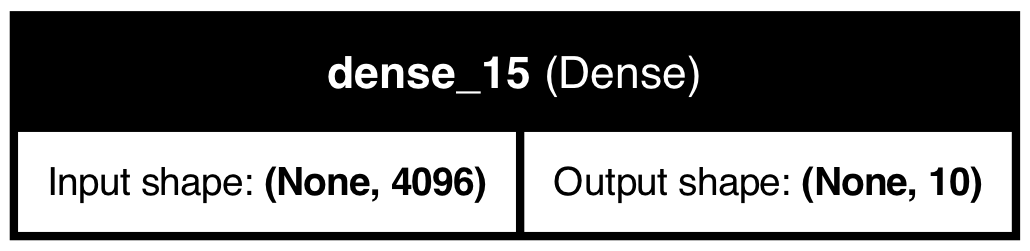

In [135]:
# Network architecture visualization
# pip install pydot graphviz
plot_model(model, to_file='model_one.png', show_shapes=True, show_layer_names=True)

##### 3.1.2 Model 2

Model 2 is the second deep learning model, adding an additional fully connected hidden layer (with 128 nodes) to the Model 1. 

The model achieves the test accuracies of **0.4468, 0.4888, and 0.7115 at epochs 10, 15, and 20, respectively**. The network architecture visualization is as follows.

Adding a hidden layer increased the model’s capacity to learn non-linear patterns in the data. In this case, **it led to a significant improvement in accuracy, from 0.6344 to 0.7115**, suggesting that the model is now better able to capture more complex patterns in the data that the single-layer model could not. However, in some cases can lead to overfitting, particular with small datasets, which may result in worsen accuracy. For instance, at the 13th and the 11th epoch, accuracy slightly decreased compared to the 12th and the 10th epoch, which may indicate the beginning of overfitting or natural fluctuations during training.

In [182]:
model2 = Sequential()
model2.add(Input(shape=(4096,)))                    # Input layer
model2.add(Dense(128, activation='relu'))           # Hidden layer (128 nodes)
model2.add(Dense(num_classes, activation='softmax'))  # Output layer

model2.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [183]:
history2 = model2.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=2
)

Epoch 1/20
36/36 - 0s - 9ms/step - accuracy: 0.3834 - loss: 9.0418 - val_accuracy: 0.4588 - val_loss: 1.0748
Epoch 2/20
36/36 - 0s - 2ms/step - accuracy: 0.4471 - loss: 1.0269 - val_accuracy: 0.3000 - val_loss: 1.1219
Epoch 3/20
36/36 - 0s - 3ms/step - accuracy: 0.4534 - loss: 0.9966 - val_accuracy: 0.4706 - val_loss: 1.0831
Epoch 4/20
36/36 - 0s - 3ms/step - accuracy: 0.4623 - loss: 0.9852 - val_accuracy: 0.4353 - val_loss: 0.9842
Epoch 5/20
36/36 - 0s - 3ms/step - accuracy: 0.4932 - loss: 0.9716 - val_accuracy: 0.4451 - val_loss: 0.9789
Epoch 6/20
36/36 - 0s - 2ms/step - accuracy: 0.4911 - loss: 0.9499 - val_accuracy: 0.3255 - val_loss: 1.1029
Epoch 7/20
36/36 - 0s - 2ms/step - accuracy: 0.4440 - loss: 1.0506 - val_accuracy: 0.3843 - val_loss: 1.3708
Epoch 8/20
36/36 - 0s - 3ms/step - accuracy: 0.5098 - loss: 1.0029 - val_accuracy: 0.4608 - val_loss: 0.9556
Epoch 9/20
36/36 - 0s - 3ms/step - accuracy: 0.5129 - loss: 0.9117 - val_accuracy: 0.6686 - val_loss: 0.9951
Epoch 10/20
36/36 -

In [ ]:
test_loss2, test_accuracy2 = model2.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"Model Two Test Accuracy: {test_accuracy2:.4f}")

✅ Model Two Test Accuracy: 0.7115


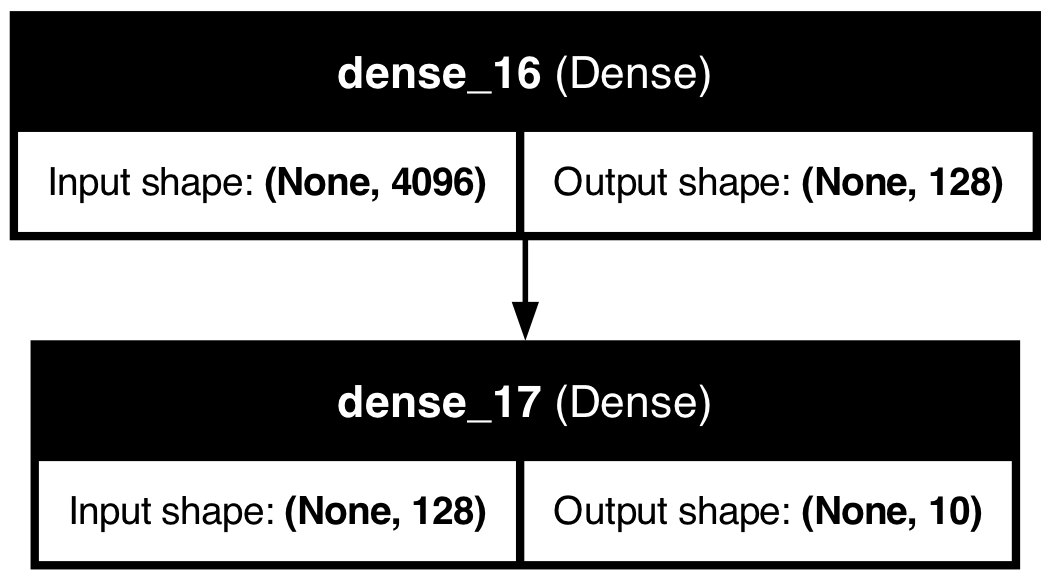

In [139]:
plot_model(model2, to_file='model_two.png', show_shapes=True, show_layer_names=True)

##### 3.1.3 Model 3

Model 3 is the third deep learning model, adding two additional fully connected hidden layers (with 256 nodes for the first hidden layer, 128 nodes for the second hidden layer, and 64 nodes for the third hidden layer), and three dropouts.

The Model 3 achieves the test accuracies of **0.7324, 0.7329, and 0.6376 at epochs 10, 15, and 20, respectively**. The network architecture visualization is as follows.

Adding another hidden layer increased the model’s capacity to learn non-linear patterns in the data. As the previous case, it led to a modest improvement in accuracy, from 0.7115 to 0.7329. However, the highest accuracy of the model 3 was 0.7329 at epochs 15, not at epochs 20. This suggests that while the model improved initially, it may have begun to overfit after a certain point. It occurs when the model starts memorizing the training data rather than generalizing well to unseen data. To improve this, early stopping or regularization techniques such as dropout could be helpful.

In [230]:
model3 = Sequential()
model3.add(Input(shape=(4096,)))            # Input layer
model3.add(Dense(256, activation='relu'))   # Hidden Layer 1
model3.add(Dropout(0.3))                    # Dropout Layer 1
model3.add(Dense(128, activation='relu'))   # Hidden Layer 2
model3.add(Dropout(0.3))                    # Dropout Layer 2
model3.add(Dense(64, activation='relu'))    # Hidden Layer 3
model3.add(Dropout(0.3))                    # Dropout Layer 3
model3.add(Dense(num_classes, activation='softmax'))  # Output layer

model3.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,634 (4.16 MB)

 Trainable params: 1,090,634 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

In [231]:
history3 = model3.fit(
    X_train_dl, y_train_dl,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=2
)

Epoch 1/15
36/36 - 1s - 16ms/step - accuracy: 0.2972 - loss: 4.0508 - val_accuracy: 0.4373 - val_loss: 1.4488
Epoch 2/15
36/36 - 0s - 5ms/step - accuracy: 0.3828 - loss: 1.3587 - val_accuracy: 0.5843 - val_loss: 1.2093
Epoch 3/15
36/36 - 0s - 5ms/step - accuracy: 0.4044 - loss: 1.2455 - val_accuracy: 0.7608 - val_loss: 1.0126
Epoch 4/15
36/36 - 0s - 5ms/step - accuracy: 0.4573 - loss: 1.1357 - val_accuracy: 0.6196 - val_loss: 0.9980
Epoch 5/15
36/36 - 0s - 5ms/step - accuracy: 0.4725 - loss: 1.0922 - val_accuracy: 0.8059 - val_loss: 0.8666
Epoch 6/15
36/36 - 0s - 5ms/step - accuracy: 0.5124 - loss: 1.0351 - val_accuracy: 0.7294 - val_loss: 0.8815
Epoch 7/15
36/36 - 0s - 5ms/step - accuracy: 0.5200 - loss: 1.0038 - val_accuracy: 0.5804 - val_loss: 0.8914
Epoch 8/15
36/36 - 0s - 5ms/step - accuracy: 0.5551 - loss: 0.9534 - val_accuracy: 0.7471 - val_loss: 0.8170
Epoch 9/15
36/36 - 0s - 5ms/step - accuracy: 0.5643 - loss: 0.9336 - val_accuracy: 0.6314 - val_loss: 0.7686
Epoch 10/15
36/36 

In [232]:
test_loss3, test_accuracy3 = model3.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"Model Three Test Accuracy: {test_accuracy3:.4f}")

Model Three Test Accuracy: 0.7329


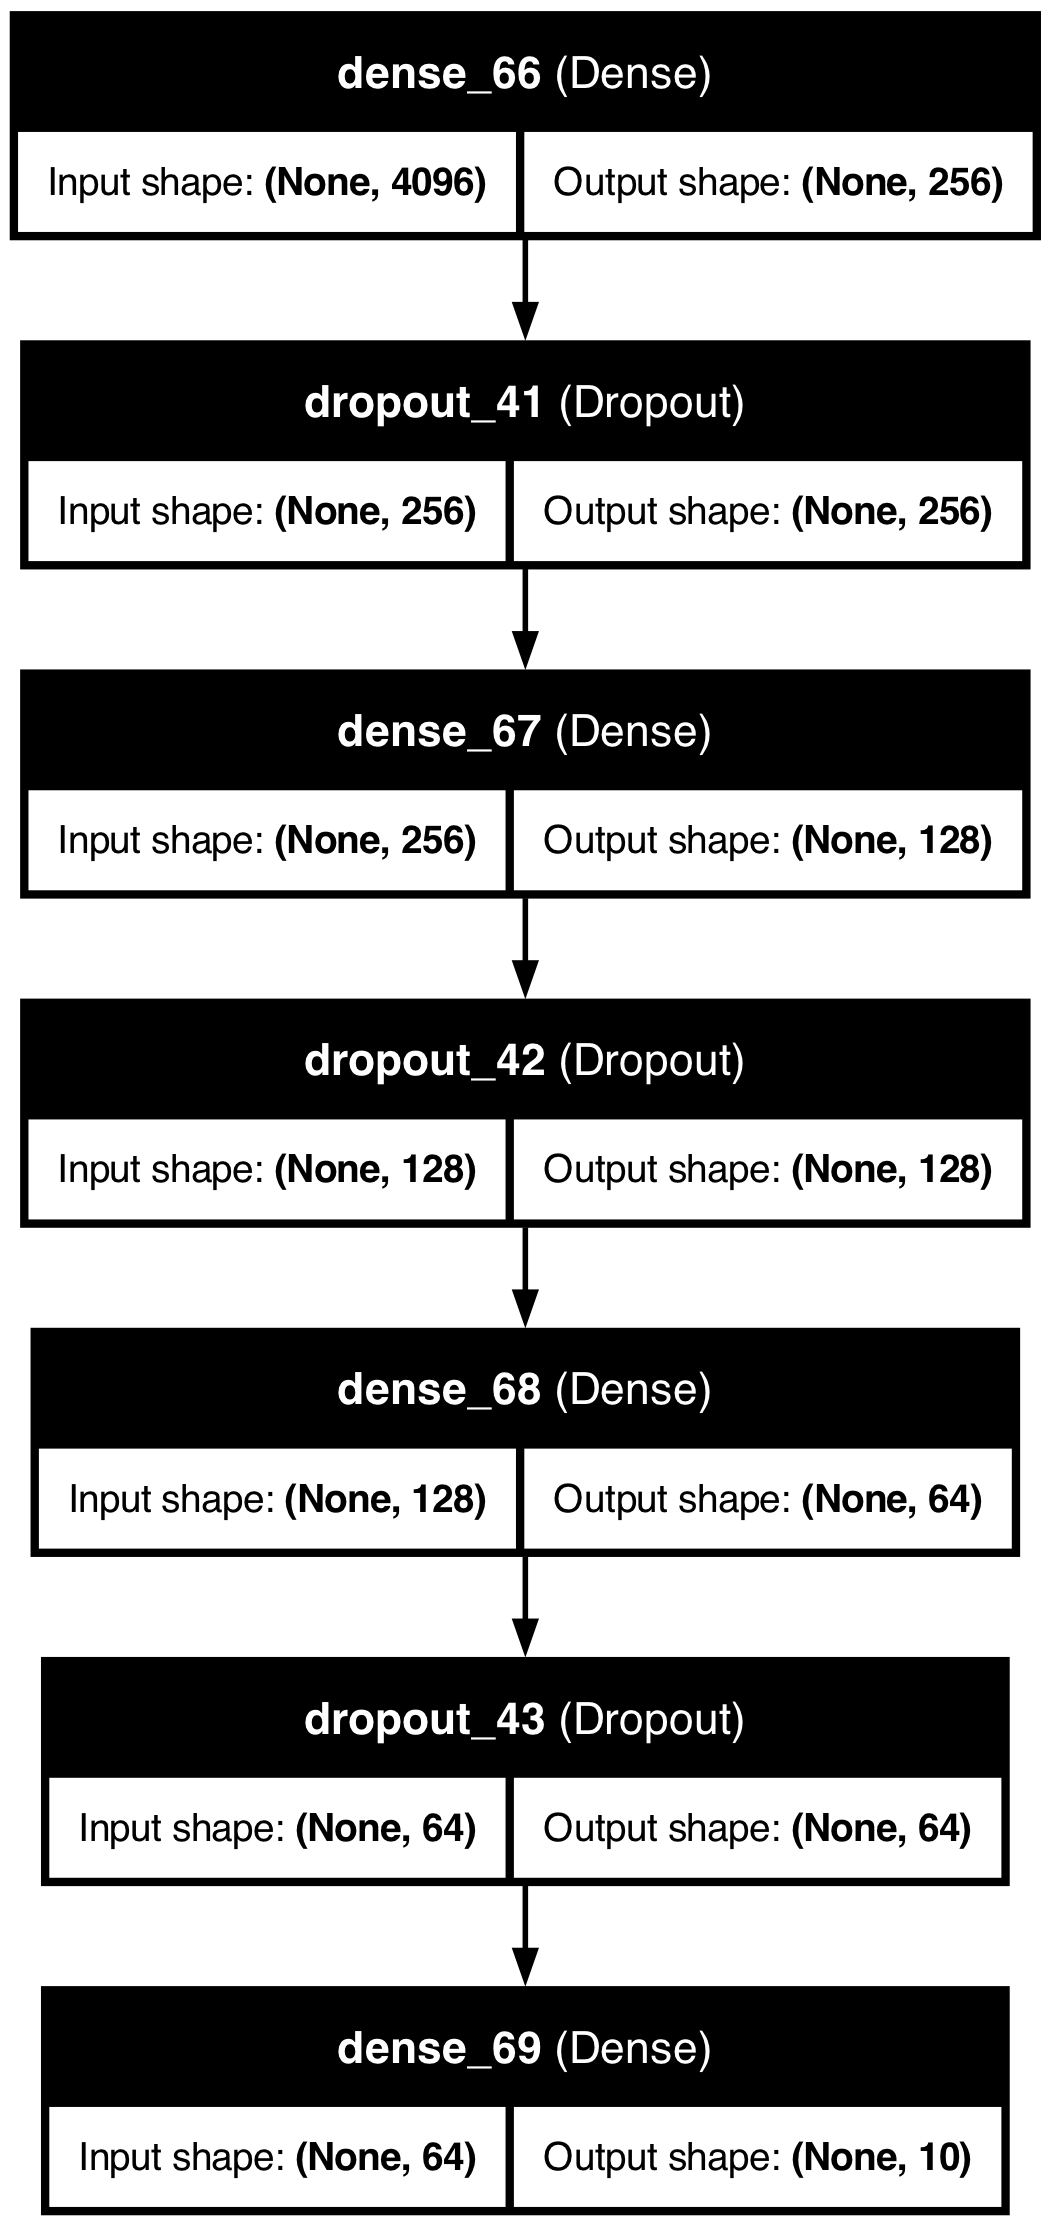

In [233]:
from IPython.display import Image
plot_model(model3, to_file='model_three.png', show_shapes=True, show_layer_names=True)
Image(filename='model_three.png')

##### 3.1.4 Model Comparison

**Which network had the most parameters to learn, and by what margin?**

Since the input size is 4,096, which is flattened 64 × 64 pixels grayscale image, and output size is 10 for 10 classes, the number of parameters for three models are as follows.

Model 1: 
- Weights: 4,096 × 10 = 40,960  
- Biases: 10  
- Total = 40,960 + 10 = 40,970 parameters

Model 2: 

    1. First layer:
        • 4,096 × 128 = 524,288
        • +128 biases = 524,416
	
    2. Output layer:
        • 128 × 10 = 1,280
        • +10 biases = 1,290

- Total = 524,416 + 1,290 = 525,706 parameters

- Margin between Model 1 and 2: 484,736

Model 3: 

    1. First layer:
        • 4,096 × 256 = 1,048,576
        • +256 biases = 1,048,832

	2. Second layer:
	    • 256 × 128 = 32,768
        • +128 biases = 32,896

    3. Third layer:
	    • 128 × 64 = 8,192
	    • +64 biases = 8,256

	4. Output layer:
	    • 64 × 10 = 640
	    • +10 biases = 650

- Total = 1,048,832 + 32,896 + 8,256 + 650 = 1,090,634 parameters

- Margin between Model 2 and 3: 564,928

**Which model was the "best"? Why?**

**Model 3 at epoch 15** was the best because the accuracy is the highest.

**For each model, what is the impact of increasing the number of training epochs?**

Training each model for 10, 15, and 20 epochs showed that increasing the number of training epochs had a positive effect on the Model 1 and 2, but **not on Model 3 beyond epoch 15.** Model 1, being shallow, showed gradual improvement as it learned basic patterns. Model 2 benefited consistently from longer training, showing strong improvement by epoch 20 (0.4468 → 0.4888 → 0.7115). Model 3, which has the highest capacity, showed rapid improvement early on but began to slightly overfit after epoch 15, with accuracy dipping at epoch 20. This suggests that **deeper models with higher capacity may require more careful training management to prevent overfitting and maintain generalization performance.**

#### 3.2 RGB Images

##### 3.2.1 Model Four

Model 4 is a deep learning model of a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. **The original RGB images, not grayscaled tif images, were used.**

The Model 4 achieves the test accuracies of **0.6344, 0.7351, and 0.8052 at epochs 10, 15, and 20, respectively**. The network architecture visualization is as follows.

**Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?**

**The Model 4 (at epoch 20)** was the best-performing model in terms of test accuracy and overall generalization. It outperformed the fully connected models (Model 1–3) because it was able to:
	•	Capture local spatial patterns (like edges, textures)
	•	Preserve the 2D structure of the image
	•	Learn hierarchical representations that are meaningful for visual tasks like land cover classification

In terms of training speed, Model 4 took **3 minutes 30 seconds** to train for 15 epochs, while Model 3 took only **15 seconds** for the same epochs. The input data of model 4 was 64 × 64 × 3, while the input data of model 3 was 64 × 64 × 1 and the Model 4 has more complex architecture than Model 3.

**How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification?**

Fully connected models flatten the image, which causes them to lose the original spatial structure, whereas CNNs maintain the spatial layout (height - width - channels) throughout the convolutional layers. Fully connected models have no notion of position or locality, treating all inputs as equally connected. In contrast, CNNs capture local, position-invariant features by applying filters across spatial neighborhoods. Finally, fully connected models treat every pixel independently, whereas CNN models learn local patterns with filters (edges, corners, textures) using shared convolutional filters.

In image classification, CNNs can recognize patterns regardless of position or scale, and they can handle natural variations in real-world images. Consequently, they generalize better across different samples of the same class.

**Why do CNNs generally require more computational resources?**

CNNs generally require more computational resources than fully connected networks because they perform complex operations — such as convolutions and pooling — across 3D tensors (height × width × channels). They use multiple filters per layer, each with its own learnable parameters, and often involve deep hierarchies of layers. This results in increased matrix computations, memory usage, and training time. As a result, GPU acceleration is often necessary for efficient training, especially on larger datasets.

In [239]:
from PIL import Image

image_size = (64, 64)
X_rgb = []
y_rgb = []

class_names = sorted([
    d for d in os.listdir(RGB_dir)
    if os.path.isdir(os.path.join(RGB_dir, d))
])

for class_name in tqdm(class_names, desc="Loading RGB images"):
    class_path = os.path.join(RGB_dir, class_name)
    for file in os.listdir(class_path):
        if file.endswith(".jpg"):
            img_path = os.path.join(class_path, file)
            img = Image.open(img_path).resize(image_size).convert("RGB")
            img_array = np.asarray(img)
            X_rgb.append(img_array)
            y_rgb.append(class_name)

X_rgb = np.array(X_rgb)
y_rgb = np.array(y_rgb)

Loading RGB images: 100%|██████████| 10/10 [00:08<00:00,  1.25it/s]


In [240]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_rgb)
y_onehot = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_rgb, y_onehot, test_size=0.4, random_state=42, stratify=y_encoded
)

# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

num_classes = y_onehot.shape[1]

In [241]:
model4 = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model4.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,962 (8.08 MB)

 Trainable params: 2,117,962 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

In [242]:
history4 = model4.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=2
)

Epoch 1/15
114/114 - 13s - 115ms/step - accuracy: 0.2128 - loss: 2.0554 - val_accuracy: 0.4333 - val_loss: 1.6341
Epoch 2/15
114/114 - 13s - 113ms/step - accuracy: 0.3655 - loss: 1.6313 - val_accuracy: 0.4475 - val_loss: 1.5195
Epoch 3/15
114/114 - 14s - 118ms/step - accuracy: 0.4236 - loss: 1.4935 - val_accuracy: 0.5358 - val_loss: 1.3228
Epoch 4/15
114/114 - 13s - 116ms/step - accuracy: 0.4605 - loss: 1.4081 - val_accuracy: 0.5500 - val_loss: 1.2362
Epoch 5/15
114/114 - 14s - 119ms/step - accuracy: 0.4739 - loss: 1.3683 - val_accuracy: 0.5802 - val_loss: 1.1274
Epoch 6/15
114/114 - 14s - 122ms/step - accuracy: 0.5024 - loss: 1.3111 - val_accuracy: 0.6253 - val_loss: 1.0760
Epoch 7/15
114/114 - 14s - 125ms/step - accuracy: 0.5356 - loss: 1.2336 - val_accuracy: 0.6142 - val_loss: 1.0217
Epoch 8/15
114/114 - 14s - 123ms/step - accuracy: 0.5320 - loss: 1.2319 - val_accuracy: 0.6469 - val_loss: 1.0028
Epoch 9/15
114/114 - 14s - 126ms/step - accuracy: 0.5561 - loss: 1.1772 - val_accuracy: 

In [243]:
test_loss4, test_accuracy4 = model4.evaluate(X_test, y_test, verbose=0)
print(f"Model Four (CNN) Test Accuracy: {test_accuracy4:.4f}")

Model Four (CNN) Test Accuracy: 0.7351


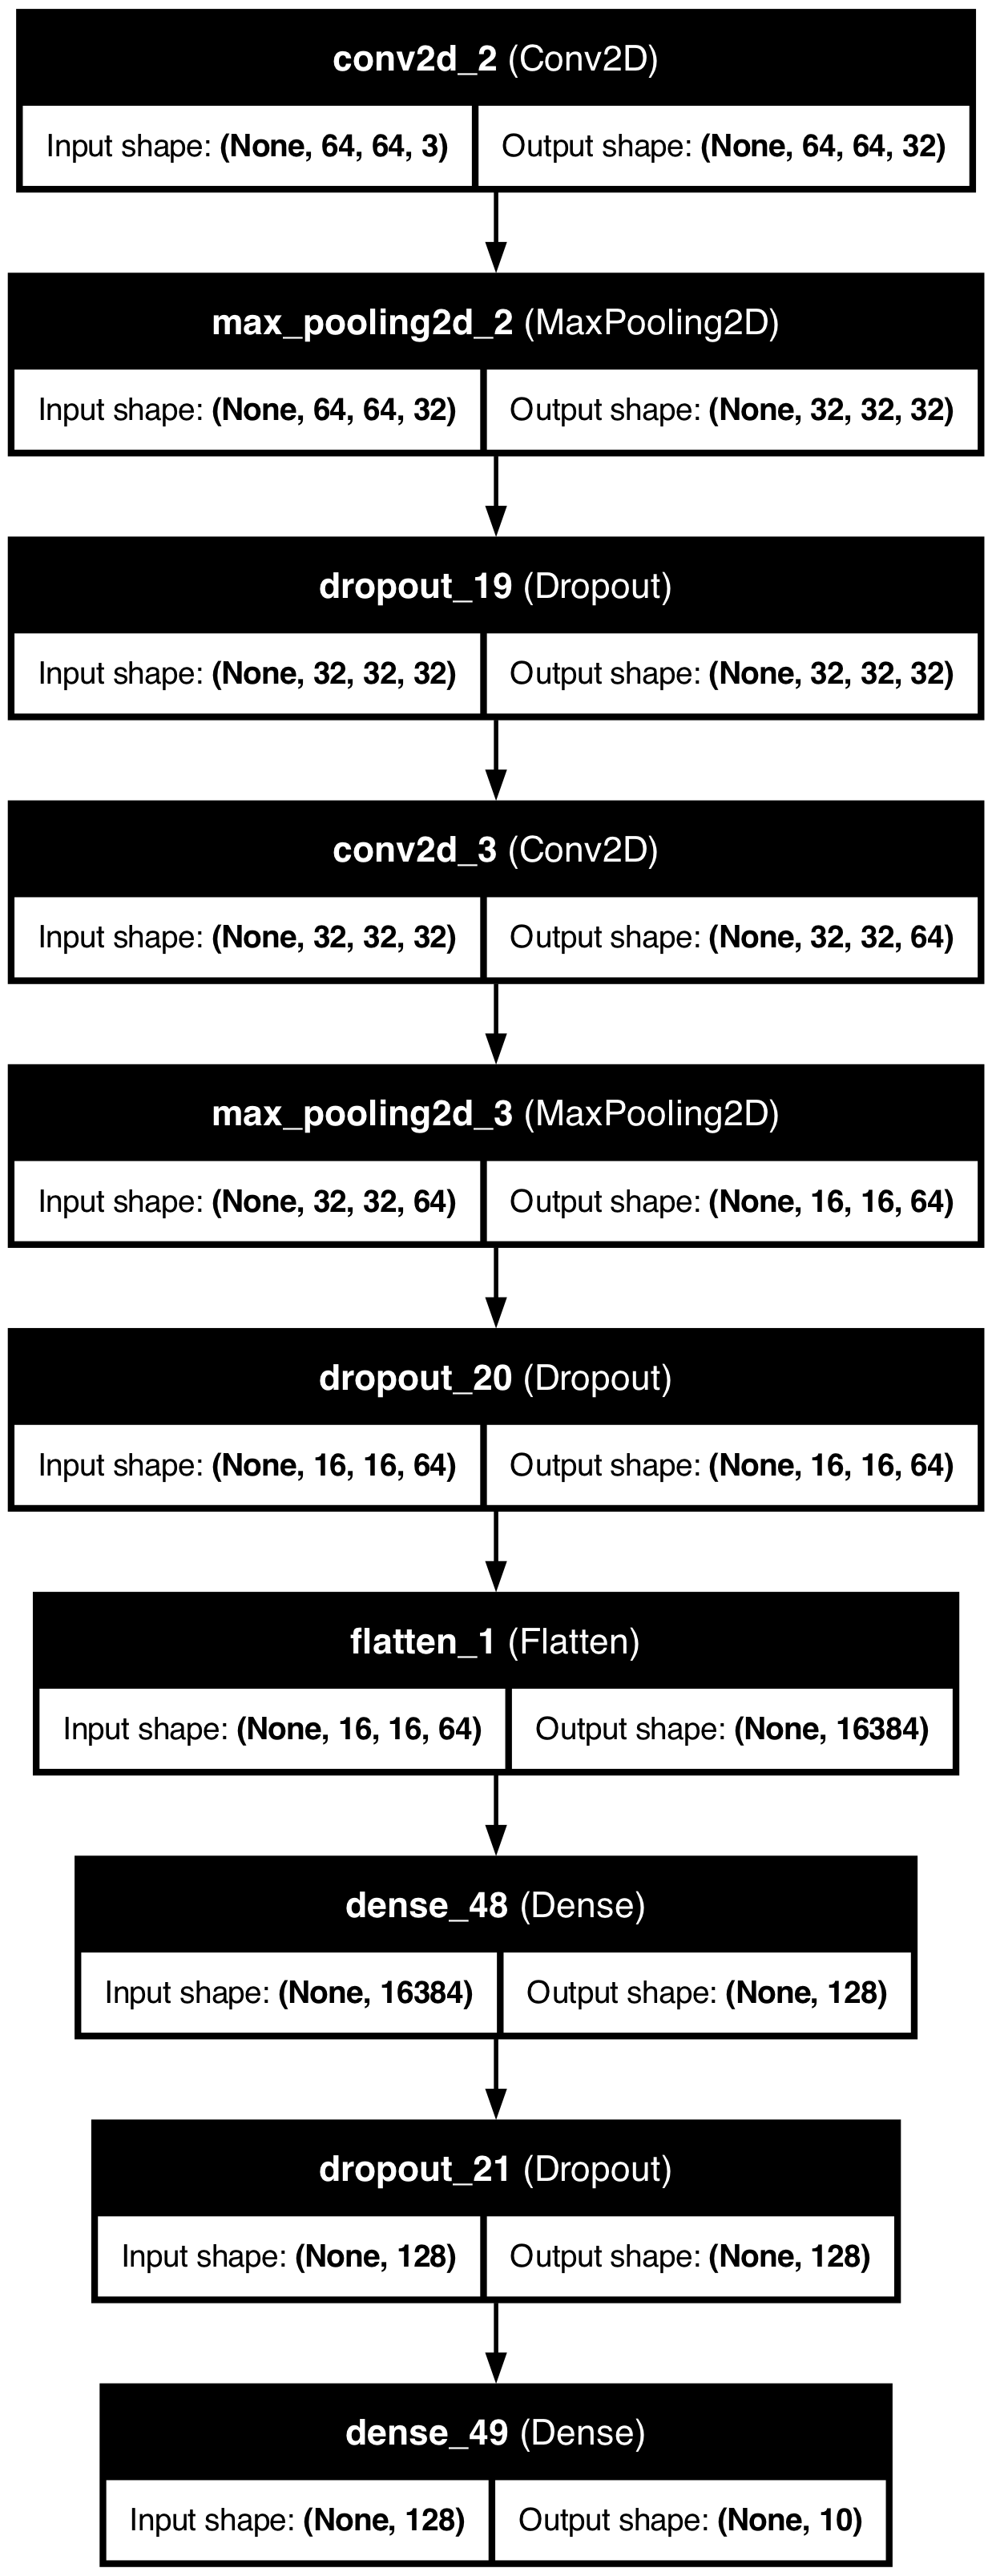

In [202]:
from IPython.display import Image
plot_model(model4, to_file='model_four.png', show_shapes=True, show_layer_names=True)
Image(filename='model_four.png')

##### 3.2.2 Model 5

The fifth deep learning model targets accuracy that will outperform all previous models.

The Model 5 achieves the test accuracies of **0.6063, 0.6216, 0.7978 and 0.7651 at epochs 10, 15, 20, and 30, respectively**. The network architecture visualization is as follows.

**What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others?**

(1) Deeper CNN structure: Model 4 had only two convolutional layers (`Conv`), while Model 5 included three convolutional layers, each followed by pooling and regularization. A deeper CNN allows the model to learn more abstract and complex features by stacking multiple layers. 

(2) BatchNormalization + Dropout: While Model 4 had dropout only, Model 5 introduces BatchNormalization after each convolutional layer, in combination with a refined Dropout strategy (0.2, 0.3, 0.4, 0.5) from 0.25, 0.25, 0.5. It helps stabilize training by normalizing activations, allowing faster convergence and reducing sensitivity to weight initialization.
	
(3) Coordinated learning rate: Both models use the Adam optimizer, but Model 5 uses a lower learning rate (0.0005). A reduced learning rate enables finer adjustments during training, which is especially beneficial for deeper networks, helping them converge more smoothly and avoid overshooting.

**Which model was the "best"? Why?**

The Model 4 is still the best and efficient model. While Model 5 was deeper and incorporated BatchNormalization and Dropout for improved generalization, its test accuracy of 0.7978 was slightly lower than Model 4’s 0.8052 at the same number of epochs, and it took longer time (around 10 minutes) than Model 4. This may be due to underfitting from aggressive dropout, a slower learning rate, or the model requiring more training epochs to converge. However, in the number of epochs 30, the accuracy was worse (0.7651). 

**What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is?**

According to the confusion matrix at epoch 30, the two classes with the highest labeling error were **Pasture (Error Rate: 47.75%)** and **SeaLake (Error Rate: 42.58%)**. In most misclassified cases, these classes were incorrectly predicted as Forest. After observing the misclassified images, it can be concluded that the model struggles to distinguish between Forest and certain land cover types that may have similar textures or color patterns in RGB imagery.

**Can you think of any strategies or approaches that might help to address this issue?**

Adding additional spectral bands, such as near-infrared (NIR), could improve the model’s ability to distinguish between visually similar classes. For example, NIR is sensitive to vegetation health and structure, which could help separate Forest from Pasture, even when they look similar in RGB.

In [252]:
from keras.layers import BatchNormalization

model5 = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model5.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model5.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,122 (8.37 MB)

 Trainable params: 2,193,674 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [253]:
history5 = model5.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    verbose=2
)

Epoch 1/30
114/114 - 27s - 233ms/step - accuracy: 0.4739 - loss: 1.6498 - val_accuracy: 0.0420 - val_loss: 10.4990
Epoch 2/30
114/114 - 27s - 235ms/step - accuracy: 0.6254 - loss: 1.0767 - val_accuracy: 0.1191 - val_loss: 13.9620
Epoch 3/30
114/114 - 28s - 242ms/step - accuracy: 0.6760 - loss: 0.9290 - val_accuracy: 0.0858 - val_loss: 18.8797
Epoch 4/30
114/114 - 27s - 239ms/step - accuracy: 0.7178 - loss: 0.8252 - val_accuracy: 0.1315 - val_loss: 10.0437
Epoch 5/30
114/114 - 27s - 239ms/step - accuracy: 0.7356 - loss: 0.7531 - val_accuracy: 0.3154 - val_loss: 6.0312
Epoch 6/30
114/114 - 27s - 240ms/step - accuracy: 0.7643 - loss: 0.7004 - val_accuracy: 0.4358 - val_loss: 3.2752
Epoch 7/30
114/114 - 27s - 240ms/step - accuracy: 0.7718 - loss: 0.6599 - val_accuracy: 0.7364 - val_loss: 0.9936
Epoch 8/30
114/114 - 27s - 239ms/step - accuracy: 0.7890 - loss: 0.6151 - val_accuracy: 0.5457 - val_loss: 2.9163
Epoch 9/30
114/114 - 29s - 253ms/step - accuracy: 0.7971 - loss: 0.5999 - val_accura

In [254]:
test_loss5, test_accuracy5 = model5.evaluate(X_test, y_test, verbose=0)
print(f"Model Five (Improved CNN) Test Accuracy: {test_accuracy5:.4f}")

Model Five (Improved CNN) Test Accuracy: 0.7651


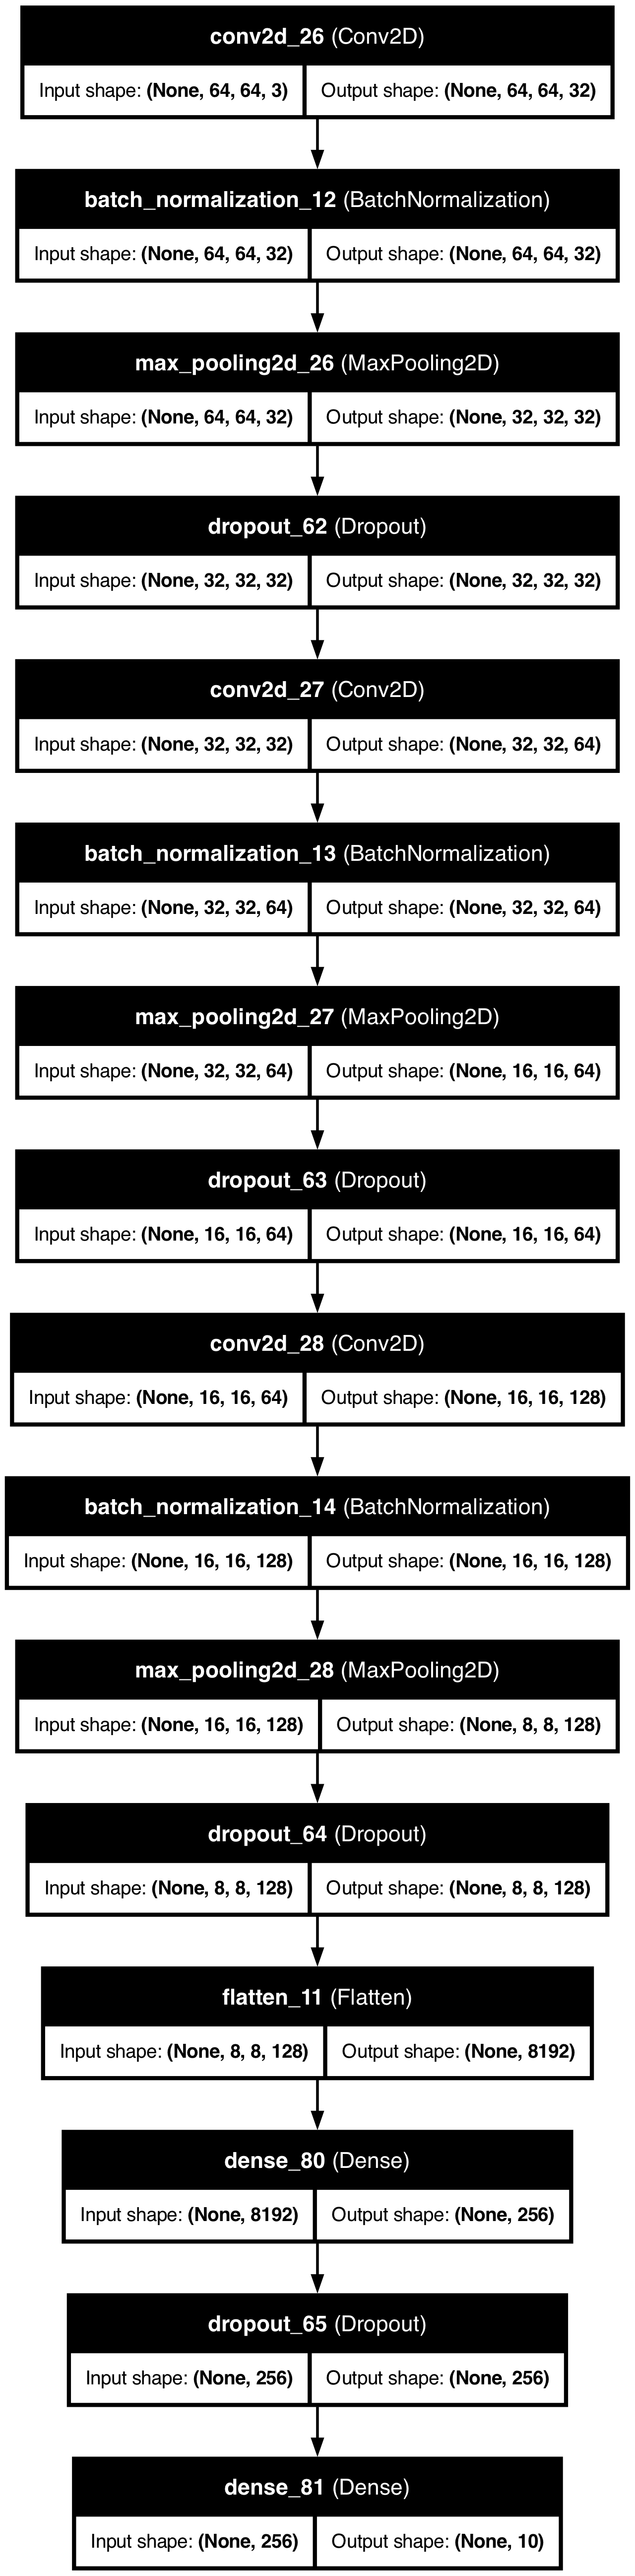

In [256]:
from IPython.display import Image
plot_model(model5, to_file='model_five.png', show_shapes=True, show_layer_names=True)
Image(filename='model_five.png')

338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


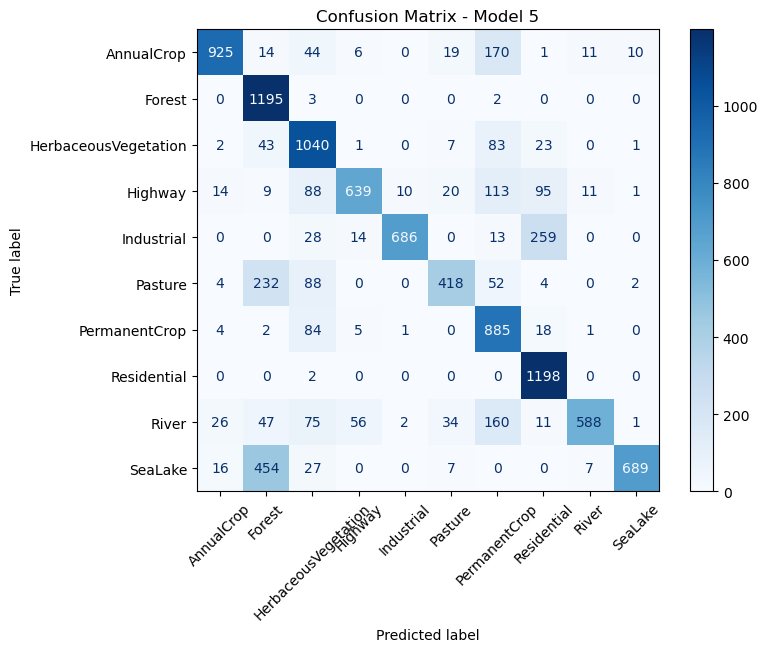

In [ ]:
# Predicted value (class index)
y_pred = np.argmax(model5.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Model 5")
plt.show()

In [ ]:
# Function to compute labeling error rate per class
def compute_labeling_error_per_class(y_true, y_pred, class_names):
    error_stats = []

    for i, class_name in enumerate(class_names):
        # Total number of samples for this class
        total = np.sum(y_true == i)

        # Misclassified samples (true = i, but predicted ≠ i)
        errors = np.sum((y_true == i) & (y_pred != i))

        # Error rate in %
        error_rate = (errors / total) * 100 if total > 0 else 0

        error_stats.append({
            "Class": class_name,
            "Total Samples": total,
            "Misclassified": errors,
            "Error Rate (%)": round(error_rate, 2)
        })

    # Display as DataFrame
    df = pd.DataFrame(error_stats)
    return df.sort_values("Error Rate (%)", ascending=False)

label_error_df = compute_labeling_error_per_class(y_true, y_pred, class_names)
print(label_error_df)

                  Class  Total Samples  Misclassified  Error Rate (%)
5               Pasture            800            382           47.75
9               SeaLake           1200            511           42.58
8                 River           1000            412           41.20
3               Highway           1000            361           36.10
4            Industrial           1000            314           31.40
0            AnnualCrop           1200            275           22.92
2  HerbaceousVegetation           1200            160           13.33
6         PermanentCrop           1000            115           11.50
1                Forest           1200              5            0.42
7           Residential           1200              2            0.17


Number of misclassified samples from ['Pasture', 'SeaLake']: 893


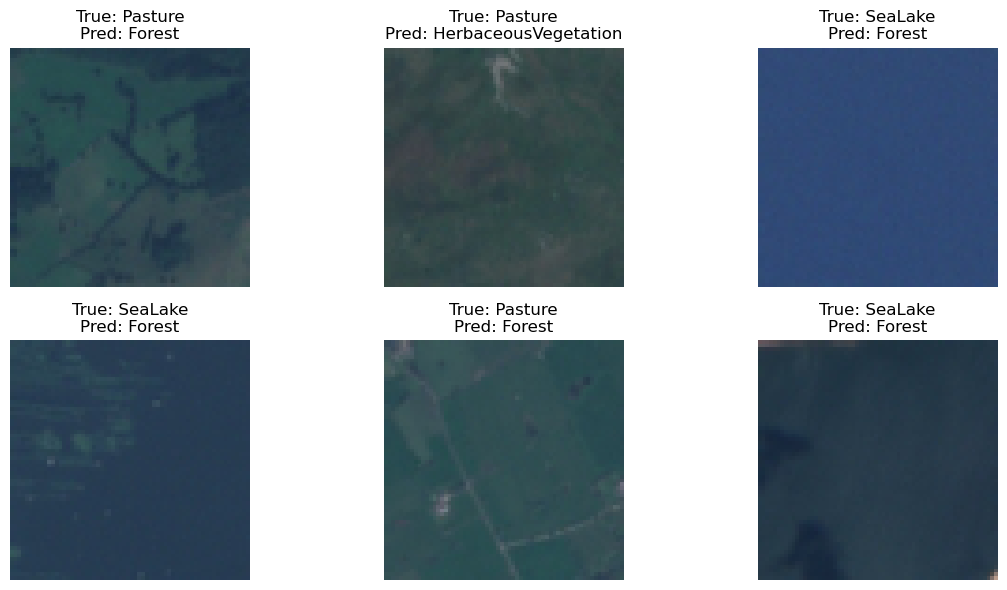

In [263]:
def plot_misclassified_specific_classes(X, y_true, y_pred, class_names, target_classes, max_images=6):
    # Find misclassified indices
    misclassified_idxs = np.where(y_true != y_pred)[0]

    # Map class names to label indices
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    target_class_indices = [class_to_index[cls] for cls in target_classes]

    # Filter only misclassified samples where true label is one of the target classes
    selected_idxs = [
        idx for idx in misclassified_idxs
        if y_true[idx] in target_class_indices
    ]

    print(f"Number of misclassified samples from {target_classes}: {len(selected_idxs)}")

    # Plot
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(selected_idxs[:max_images]):
        plt.subplot(2, 3, i + 1)
        plt.imshow(X[idx])
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_misclassified_specific_classes(
    X_test,           # your test images
    y_true,           # true labels (as integers)
    y_pred,           # predicted labels (as integers)
    class_names,      # list of class names (same order as label encoding)
    target_classes=["Pasture", "SeaLake"],  # focus on these
    max_images=6
)

#### 3.3 Multispectral Images

In this section, I applied Model 4 using the Red, Green, Blue, and NIR bands of the multispectral tif images, rather than the RGB jpg images used in Section 3.2.

The Model 4 trained with the multispectral images achieves the test accuracies of **0.8790, 0.8945, and 0.9022 at epochs 10, 15, and 20, respectively**. The network architecture visualization is as follows.

**How did adding multispectral channels impact your model’s performance? Explain the role of additional spectral information in enhancing land cover classification.**

Comparing to the Model 5, **the number of misclassified images decreased from 893 to 388**,** which indicates the performance of the model was significantly improved. Adding the NIR band had a substantial impact on the model’s performance by providing richer spectral information beyond the standard RGB bands. In particular, the inclusion of the NIR band allowed the model to detect features of water content, which are not visible in RGB imagery. The error rates of **River** and **SeaLake** decreased significantly, which suggests **NIR helps the model better distinguish between land cover types that may appear visually similar in RGB but are spectrally distinct** — for example, Forest vs. SeaLake or River vs. PermanentCrop. 

In [ ]:
from PIL import Image
X_ms = []
y_ms = []

for class_name in tqdm(class_names, desc="Loading multispectral images"):
    class_path = os.path.join(MS_dir, class_name)
    for file in os.listdir(class_path):
        if file.endswith(".tif"):
            img_path = os.path.join(class_path, file)
            try:
                with rasterio.open(img_path) as src:
                    red = src.read(4).astype(np.float32)
                    green = src.read(3).astype(np.float32)
                    blue = src.read(2).astype(np.float32)
                    nir = src.read(8).astype(np.float32)

                    stacked = np.stack([red, green, blue, nir], axis=-1)  # (H, W, 4)

                    # Normalize per image to 0–255
                    stacked_norm = (stacked - stacked.min()) / (stacked.max() - stacked.min()) * 255.0
                    stacked_uint8 = stacked_norm.astype(np.uint8)

                    img_resized = np.array(Image.fromarray(stacked_uint8).resize((64, 64)))
                    X_ms.append(img_resized)
                    y_ms.append(class_name)
            except Exception as e:
                print(f"Error reading {img_path}: {e}")

Loading multispectral images: 100%|██████████| 10/10 [01:12<00:00,  7.20s/it]


In [265]:
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y_ms)
y_onehot = to_categorical(y_encoded)
X_ms = np.array(X_ms)
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_ms, y_onehot, test_size=0.4, random_state=42, stratify=y_encoded
)

# Normalize pixel values to [0, 1] - this is still correct!
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [269]:
model4 = Sequential([
    Input(shape=(64, 64, 4)),  # (3 → 4 채널)
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model4.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [270]:
history4 = model4.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    verbose=2
)

Epoch 1/15
114/114 - 13s - 118ms/step - accuracy: 0.5257 - loss: 1.3215 - val_accuracy: 0.6864 - val_loss: 0.9070
Epoch 2/15
114/114 - 13s - 110ms/step - accuracy: 0.6840 - loss: 0.8881 - val_accuracy: 0.7599 - val_loss: 0.7206
Epoch 3/15
114/114 - 14s - 127ms/step - accuracy: 0.7375 - loss: 0.7430 - val_accuracy: 0.7414 - val_loss: 0.6878
Epoch 4/15
114/114 - 15s - 130ms/step - accuracy: 0.7711 - loss: 0.6492 - val_accuracy: 0.7901 - val_loss: 0.5328
Epoch 5/15
114/114 - 14s - 125ms/step - accuracy: 0.7941 - loss: 0.5879 - val_accuracy: 0.8296 - val_loss: 0.5047
Epoch 6/15
114/114 - 15s - 132ms/step - accuracy: 0.8116 - loss: 0.5439 - val_accuracy: 0.8364 - val_loss: 0.4473
Epoch 7/15
114/114 - 14s - 126ms/step - accuracy: 0.8217 - loss: 0.5091 - val_accuracy: 0.8420 - val_loss: 0.4519
Epoch 8/15
114/114 - 14s - 125ms/step - accuracy: 0.8346 - loss: 0.4724 - val_accuracy: 0.8463 - val_loss: 0.4248
Epoch 9/15
114/114 - 14s - 125ms/step - accuracy: 0.8498 - loss: 0.4355 - val_accuracy: 

In [271]:
test_loss4, test_accuracy4 = model4.evaluate(X_test, y_test, verbose=0)
print(f"Model Four (CNN) Test Accuracy: {test_accuracy4:.4f}")

Model Four (CNN) Test Accuracy: 0.8945


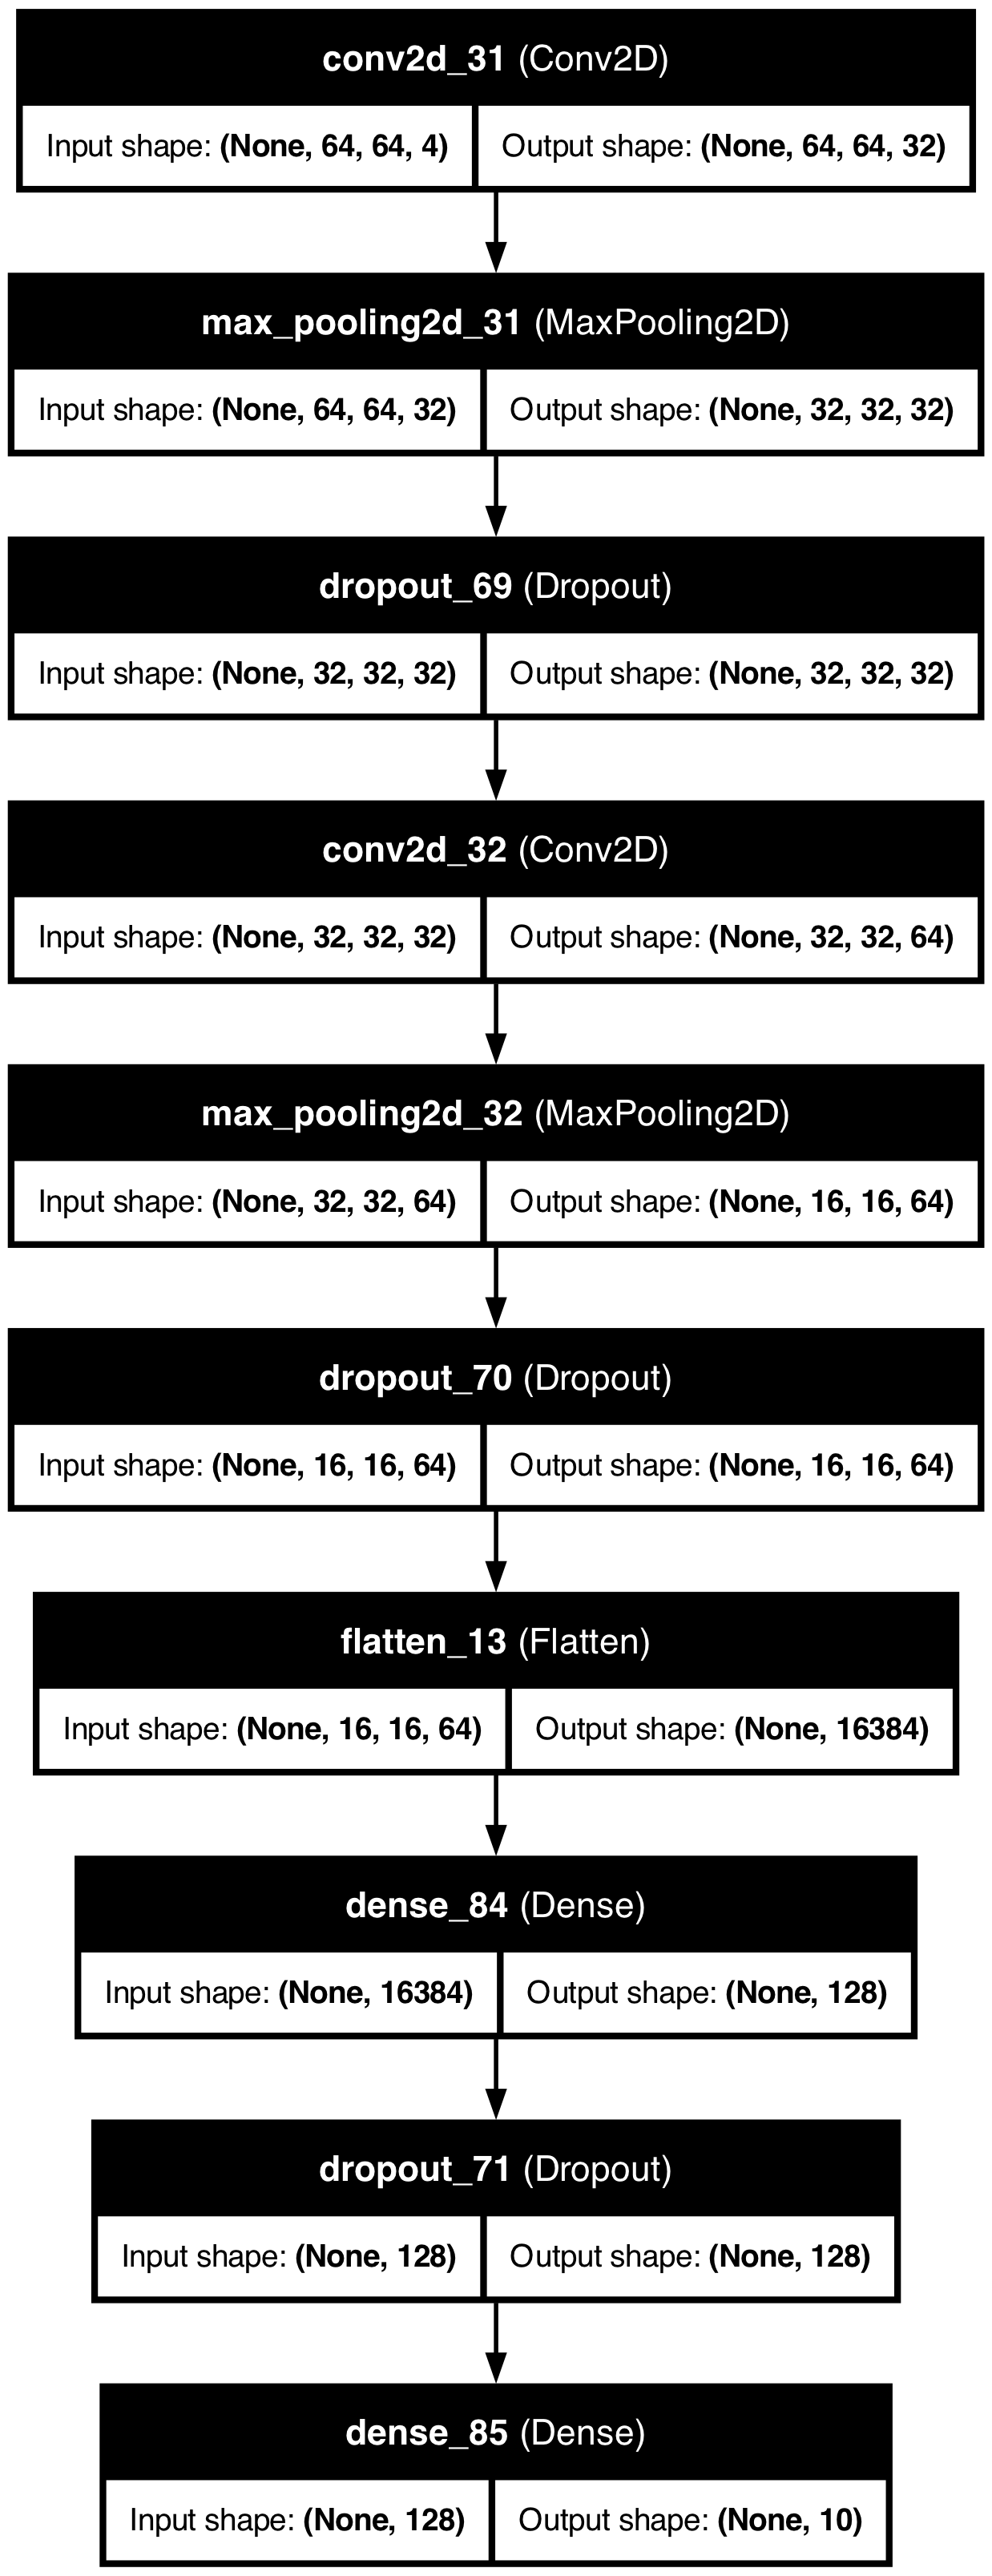

In [272]:
from IPython.display import Image
plot_model(model4, to_file='model_four-2.png', show_shapes=True, show_layer_names=True)
Image(filename='model_four-2.png')

338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


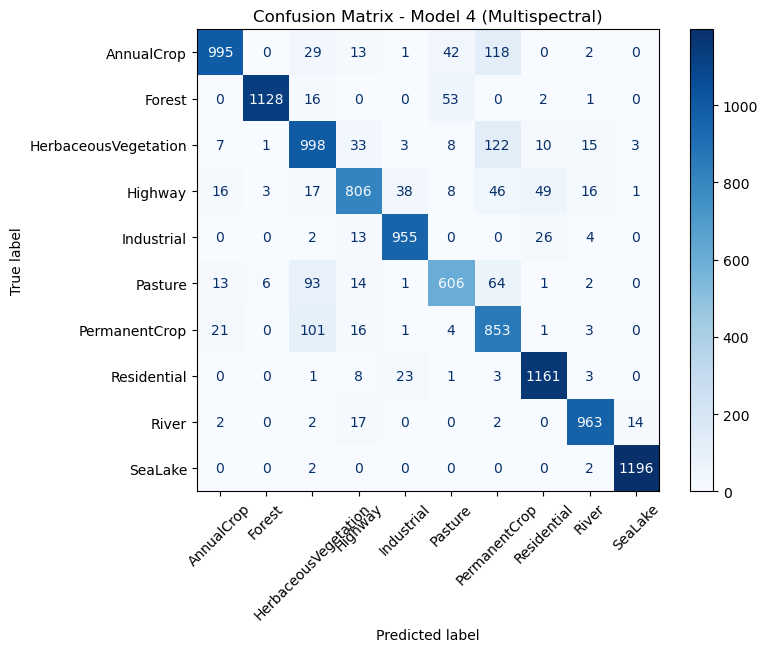

In [ ]:
# Predicted value (class index)
y_pred = np.argmax(model4.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Model 4 (Multispectral), epoch 15")
plt.show()

In [274]:
# Function to compute labeling error rate per class
def compute_labeling_error_per_class(y_true, y_pred, class_names):
    error_stats = []

    for i, class_name in enumerate(class_names):
        # Total number of samples for this class
        total = np.sum(y_true == i)

        # Misclassified samples (true = i, but predicted ≠ i)
        errors = np.sum((y_true == i) & (y_pred != i))

        # Error rate in %
        error_rate = (errors / total) * 100 if total > 0 else 0

        error_stats.append({
            "Class": class_name,
            "Total Samples": total,
            "Misclassified": errors,
            "Error Rate (%)": round(error_rate, 2)
        })

    # Display as DataFrame
    df = pd.DataFrame(error_stats)
    return df.sort_values("Error Rate (%)", ascending=False)

label_error_df = compute_labeling_error_per_class(y_true, y_pred, class_names)
print(label_error_df)

                  Class  Total Samples  Misclassified  Error Rate (%)
5               Pasture            800            194           24.25
3               Highway           1000            194           19.40
0            AnnualCrop           1200            205           17.08
2  HerbaceousVegetation           1200            202           16.83
6         PermanentCrop           1000            147           14.70
1                Forest           1200             72            6.00
4            Industrial           1000             45            4.50
8                 River           1000             37            3.70
7           Residential           1200             39            3.25
9               SeaLake           1200              4            0.33


Number of misclassified samples from ['Pasture', 'Highway']: 388


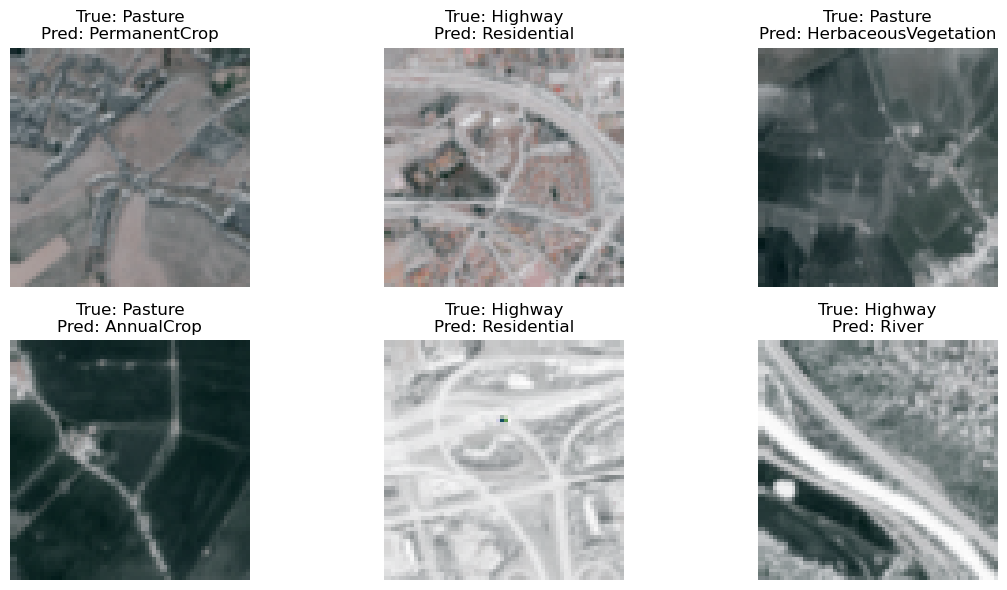

In [275]:
def plot_misclassified_specific_classes(X, y_true, y_pred, class_names, target_classes, max_images=6):
    # Find misclassified indices
    misclassified_idxs = np.where(y_true != y_pred)[0]

    # Map class names to label indices
    class_to_index = {name: idx for idx, name in enumerate(class_names)}
    target_class_indices = [class_to_index[cls] for cls in target_classes]

    # Filter only misclassified samples where true label is one of the target classes
    selected_idxs = [
        idx for idx in misclassified_idxs
        if y_true[idx] in target_class_indices
    ]

    print(f"Number of misclassified samples from {target_classes}: {len(selected_idxs)}")

    # Plot
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(selected_idxs[:max_images]):
        plt.subplot(2, 3, i + 1)
        plt.imshow(X[idx])
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_misclassified_specific_classes(
    X_test,           # your test images
    y_true,           # true labels (as integers)
    y_pred,           # predicted labels (as integers)
    class_names,      # list of class names (same order as label encoding)
    target_classes=["Pasture", "Highway"],  # focus on these
    max_images=6
)

### 4. Reflection Questions

**What are your takeaways from tuning the parameters of the different models?**

I learned smaller models improved steadily with more training, while deeper models required careful regularization and tuning to avoid overfitting.

**What are your observations about increasing the number of training epochs?**

Increasing the number of epochs generally improved model performance, especially in shallower models that required more time to learn. However, deep learning models like Model 3 and Model 5 showed overfitting beyond a certain point (e.g., after epoch 15), suggesting the need for strategies like early stopping or learning rate decay.

**Did you run into any challenges or limitations when doing this?**

Model 5 was expected to outperform Model 4 due to its deeper architecture and additional regularization techniques, but it did not. From this, I learned model performance does not always align with theoretical expectations. Additionally, because I am a beginner in deep learning, I had to observe how the model behaves through experience, that is, through trial and error.

**What was the impact of using dropout? If you answered the bonus questions, how did the ensemble models compare to the other models?**

The use of dropout in the Model 3, 4, and 5 made the training more stable and prevented the model from relying too heavily on specific neurons. Dropout helps in model training by:

(1) regularizing technique that randomly “drops” (i.e., ignores) a subset of neurons during training.

(2) forcing the network to learn redundant, distributed representations, making it less sensitive to specific features or noise.

(3) acting like training many different sub-networks and averaging them at inference time.

Dropout is effective when the model is deep or complex, while is less effective when the dataset is very large and already balanced, dropout might not help much.

**What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future?**

I believe I need to better understand and address the sensitivity of model parameters by gaining more exposure to deep learning through existing studies and hands-on practice. It is also important to gain lots of experience of preprocessing techniques.

**How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?**

In other deep learning problems such as military facility identification or change detection, the knowledge gained from this project can be applied in several ways. When training with images that contain known military facilities, I would tune parameters such as the learning rate, and the number of hidden layers and nodes to find optimal values for the task. To prevent the model from overfitting or relying too heavily on specific neurons, I would apply dropout to randomly deactivate parts of the network during training. Additionally, I would aim to find the optimal number of training epochs to balance underfitting and overfitting.